In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [38]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [39]:
len(words)

32033

In [40]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [41]:
# build the dataset

block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words[:3]:
  
  print('START-------------',w)
  context = [0] * block_size  # initially all 0s i.e. [0, 0, 0]
  for ch in w + '.':
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)
    print(''.join(itos[i] for i in context), '--->', itos[ix])
    context = context[1:] + [ix] # crop the last char and append ix e.g. [0, 0, 5] for `e` in emma
  print('-------------END')
  
X = torch.tensor(X)
Y = torch.tensor(Y)

START------------- emma
... ---> e
..e ---> m
.em ---> m
emm ---> a
mma ---> .
-------------END
START------------- olivia
... ---> o
..o ---> l
.ol ---> i
oli ---> v
liv ---> i
ivi ---> a
via ---> .
-------------END
START------------- ava
... ---> a
..a ---> v
.av ---> a
ava ---> .
-------------END


In [42]:
# X (input) is a [number of examples, block size] matrix
# Y (output) is a [number of examples] vector
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([16, 3]), torch.int64, torch.Size([16]), torch.int64)

In [ ]:
# The objective is to embed 3 character sequence in 2-d space
# Initialising weight matrix - with 27 charactes in 2 dimensions
# The paper talks about embedding 17K words in 30 dimensional space
C = torch.randn((27, 2))

In [44]:
C[5]

tensor([0.3290, 1.5268])

In [45]:
F.one_hot(torch.tensor(5), num_classes=27).float() # one-hot encoding

tensor([0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0.])

Multiplying One hot by C would lead us to the same results as indexing C with the respective character index. In below example only the index 5 would be 1 and all others would be 0. So the result of the multiplication would be the same as C[5] (rest of the rows are zero and would be masked out)

In [46]:
F.one_hot(torch.tensor(5), num_classes=27).float() @ C 

tensor([0.3290, 1.5268])

#### Pytorch Indexing

In [96]:
# Pytorch indexing for list and tensors
print(C[[5, 5, 5, 2]]) #automagicallyy multiply even if you index same values
print(C[torch.tensor([5, 5, 5, 2])])
print(C[torch.tensor([5, 5, 5, 2])].shape)
print(C[X[1]].shape) # each character have 2 values in C, so a sequence of 2 will give 3x2 matrix
print(C[X].shape) #expands the shape on how you index [samples, block size, dimentions]

tensor([[ 0.3290,  1.5268],
        [ 0.3290,  1.5268],
        [ 0.3290,  1.5268],
        [-0.2141, -1.4388]])
tensor([[ 0.3290,  1.5268],
        [ 0.3290,  1.5268],
        [ 0.3290,  1.5268],
        [-0.2141, -1.4388]])
torch.Size([4, 2])
torch.Size([3, 2])
torch.Size([16, 3, 2])


In [72]:
X[1].tolist()[1] # convert to list

0

Creating the first input layer - embedding
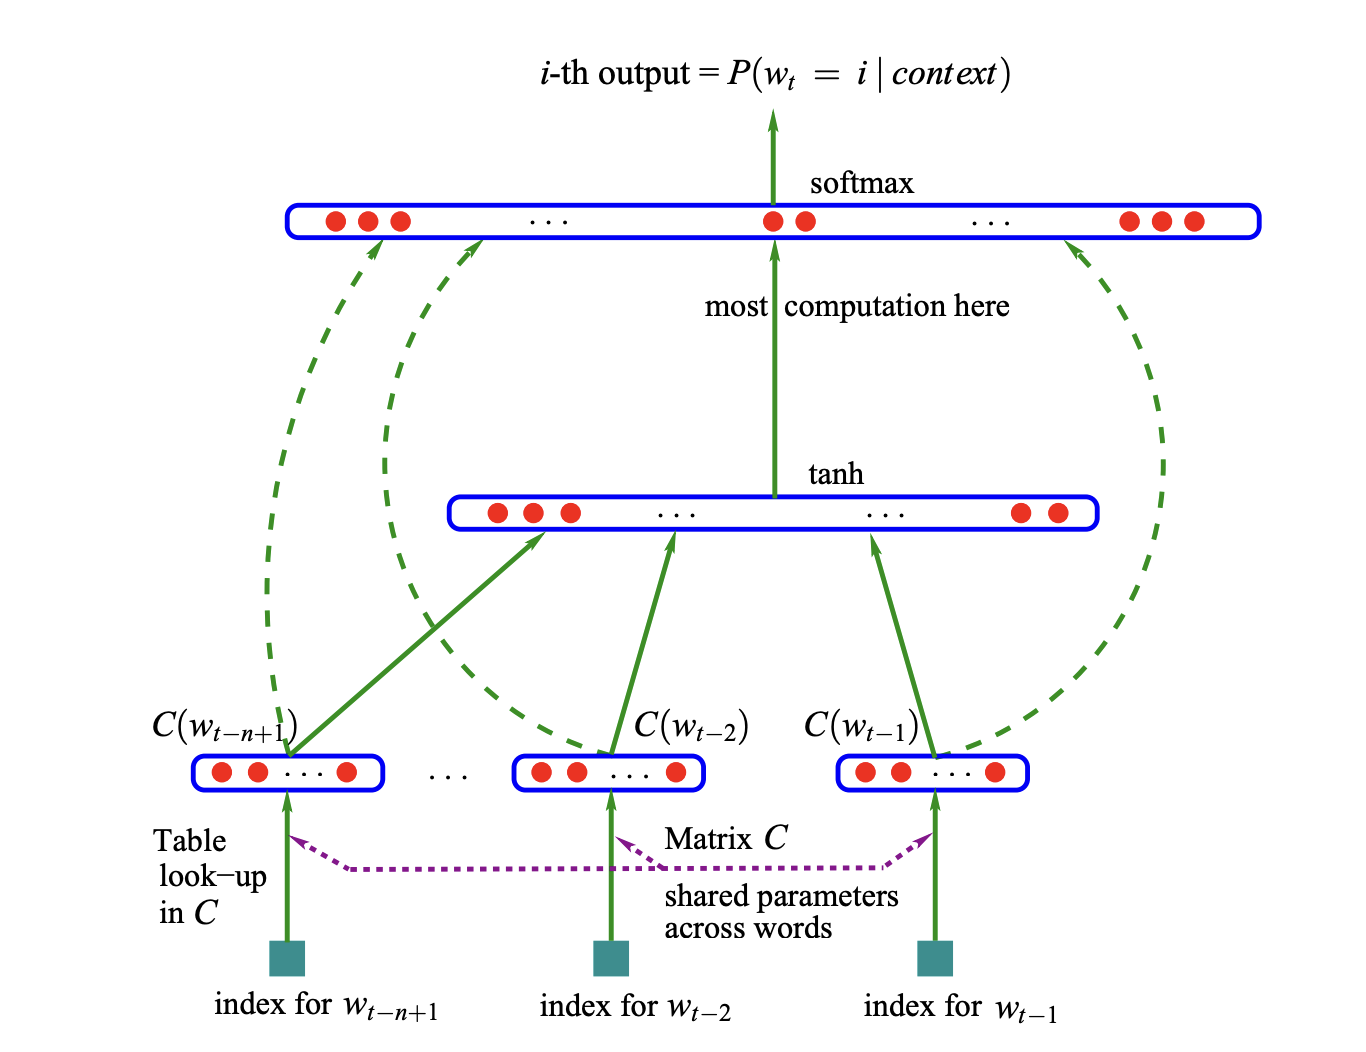

In [ ]:
# Creating embedding matrix 
emb = C[X]
print('shape of embedding:', emb.shape)
print('===============')
for i in range(5):
    items = X[i].tolist()
    print(f'sample {i+1}:', items, '==>', itos[items[0]], itos[items[1]], itos[items[2]])
    print(f'embedding for sample {i+1}: \n', emb[i])
    print('===============')

# embedding size is [number of examples, block size, dimention size]


shape of embedding: torch.Size([16, 3, 2])
sample 1: [0, 0, 0] ==> . . .
embedding for sample 1: 
 tensor([[ 0.1207, -0.0768],
        [ 0.1207, -0.0768],
        [ 0.1207, -0.0768]])
sample 2: [0, 0, 5] ==> . . e
embedding for sample 2: 
 tensor([[ 0.1207, -0.0768],
        [ 0.1207, -0.0768],
        [ 0.3290,  1.5268]])
sample 3: [0, 5, 13] ==> . e m
embedding for sample 3: 
 tensor([[ 0.1207, -0.0768],
        [ 0.3290,  1.5268],
        [ 0.1442, -0.1842]])
sample 4: [5, 13, 13] ==> e m m
embedding for sample 4: 
 tensor([[ 0.3290,  1.5268],
        [ 0.1442, -0.1842],
        [ 0.1442, -0.1842]])
sample 5: [13, 13, 1] ==> m m a
embedding for sample 5: 
 tensor([[ 0.1442, -0.1842],
        [ 0.1442, -0.1842],
        [ 0.5165,  1.4791]])


We would basically want to do 
`embedding (input) @ Weights + Biases`
If we randomyly choose a weights matrix with 6 rows (3 x 2 since our block size is 3 and each character have 2 dimensions), we will not be able to multiple embeeding with weights because the shape of embedding is 3 dimentional tensor vs 2 dimensional tensor of weights. We need to reshape the embedding to 2D tensor. 

In [98]:
W1 = torch.randn((6, 100))
b1 = torch.randn(100)

In [112]:
# Pluck the 2D for each character and then contact to convert 3x2 into 1x6
torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], 1).shape


torch.Size([16, 6])

The problem with above approach is that we are hardcoding the block size. When we change the bolck size from 3 to 5 then the code will break. Alternative way is to use `view` method of pytorch tensor.

In [118]:
eg = torch.arange(10)
print(eg)
print(eg.view(2, 5))

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
tensor([[0, 1, 2, 3, 4],
        [5, 6, 7, 8, 9]])


In [121]:
# We can acrive to the same result
emb.view(-1, 6).shape # -1 means infer the size

torch.Size([16, 6])

#### Creating the second layer - hidden layer tanh

In [122]:
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)

In [123]:
h

tensor([[ 0.6414, -0.2580,  0.7209,  ...,  0.1903,  0.8674, -0.9533],
        [ 0.4587, -0.9905,  0.6372,  ..., -0.1977,  0.9836,  0.9674],
        [ 0.9974,  0.9324,  0.7589,  ..., -0.7985, -0.3427, -0.9389],
        ...,
        [ 0.3427, -0.9808,  0.8126,  ..., -0.0742,  0.9822,  0.9873],
        [ 0.9985, -0.4251,  0.4107,  ..., -0.9287,  0.3396, -0.5571],
        [ 0.9962,  0.6904,  0.9602,  ...,  0.6234,  0.9938,  0.9998]])

In [124]:
h.shape

torch.Size([16, 100])

In [125]:
W2 = torch.randn((100, 27))
b2 = torch.randn(27)

In [126]:
logits = h @ W2 + b2

In [127]:
logits.shape

torch.Size([16, 27])

In [128]:
counts = logits.exp()

In [129]:
prob = counts / counts.sum(1, keepdims=True)

In [130]:
prob.shape

torch.Size([16, 27])

In [132]:
loss = -prob[torch.arange(16), Y].log().mean()
loss

tensor(16.3154)

Put it all together

In [142]:
block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words[:3]:
  
  print('START-------------',w)
  context = [0] * block_size  # initially all 0s i.e. [0, 0, 0]
  for ch in w + '.':
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)
    print(''.join(itos[i] for i in context), '--->', itos[ix])
    context = context[1:] + [ix] # crop the last char and append ix e.g. [0, 0, 5] for `e` in emma
  print('-------------END')
  
X = torch.tensor(X)
Y = torch.tensor(Y)
print(f'X [No of samples, context length]: {X.shape}')
print(f'Y [output labels]: {Y.shape}')

emb = C[X]
print('shape of embedding: [No of samples, context length, dimentions]: ', emb.shape)

# initialisation with 100 neurons
W1 = torch.randn((6, 100))
b1 = torch.randn(100)
print('shape of W1 [context length x dimention, Arbitory no of Neurons]:', W1.shape)
print('shape of b1:', b1.shape)

h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
print('shape of h:', h.shape)

W2 = torch.randn((100, 27))
b2 = torch.randn(27)
print('shape of W2:', W2.shape)
print('shape of b2:', b2.shape)

logits = h @ W2 + b2
print('shape of logits:', logits.shape)
counts = logits.exp()
print('shape of counts:', counts.shape)
prob = counts / counts.sum(1, keepdims=True)
print('shape of prob:', prob.shape)
loss = -prob[torch.arange(16), Y].log().mean()
print('loss:', loss)



START------------- emma
... ---> e
..e ---> m
.em ---> m
emm ---> a
mma ---> .
-------------END
START------------- olivia
... ---> o
..o ---> l
.ol ---> i
oli ---> v
liv ---> i
ivi ---> a
via ---> .
-------------END
START------------- ava
... ---> a
..a ---> v
.av ---> a
ava ---> .
-------------END
X [No of samples, context length]: torch.Size([16, 3])
Y [output labels]: torch.Size([16])
shape of embedding: [No of samples, context length, dimentions]:  torch.Size([16, 3, 2])
shape of W1 [context length x dimention, Arbitory no of Neurons]: torch.Size([6, 100])
shape of b1: torch.Size([100])
shape of h: torch.Size([16, 100])
shape of W2: torch.Size([100, 27])
shape of b2: torch.Size([27])
shape of logits: torch.Size([16, 27])
shape of counts: torch.Size([16, 27])
shape of prob: torch.Size([16, 27])
loss: tensor(13.3338)


Leveraging torch cross entropy loss function over manual computation of loss function. Because

- torch uses fused kernel instead of manually creating so many tensors (which is memory efficient)
- simplify the mathematical computation and derivatives

In [143]:
F.cross_entropy(logits, Y)

tensor(13.3338)

In [ ]:
# ------------ now made respectable :) ---------------

In [150]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [151]:
Xtr.shape, Ytr.shape # dataset

(torch.Size([182625, 3]), torch.Size([182625]))

In [152]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [153]:
sum(p.nelement() for p in parameters) # number of parameters in total

11897

In [154]:
for p in parameters:
  p.requires_grad = True

In [148]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [149]:
lri = []
lossi = []
stepi = []

In [155]:
for i in range(200000):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (32,))
  
  # forward pass
  emb = C[Xtr[ix]] # (32, 3, 10)
  h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 200)
  logits = h @ W2 + b2 # (32, 27)
  loss = F.cross_entropy(logits, Ytr[ix])
  #print(loss.item())
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  #lr = lrs[i]
  lr = 0.1 if i < 100000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  #lri.append(lre[i])
  stepi.append(i)
  lossi.append(loss.log10().item())

#print(loss.item())

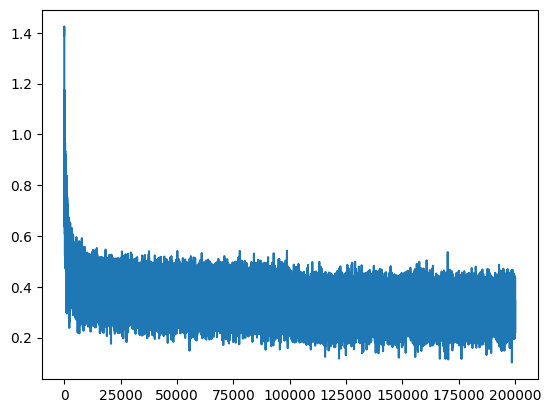

In [156]:
plt.plot(stepi, lossi)

In [157]:
emb = C[Xtr] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.1156, grad_fn=<NllLossBackward0>)

In [158]:
emb = C[Xdev] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1527, grad_fn=<NllLossBackward0>)

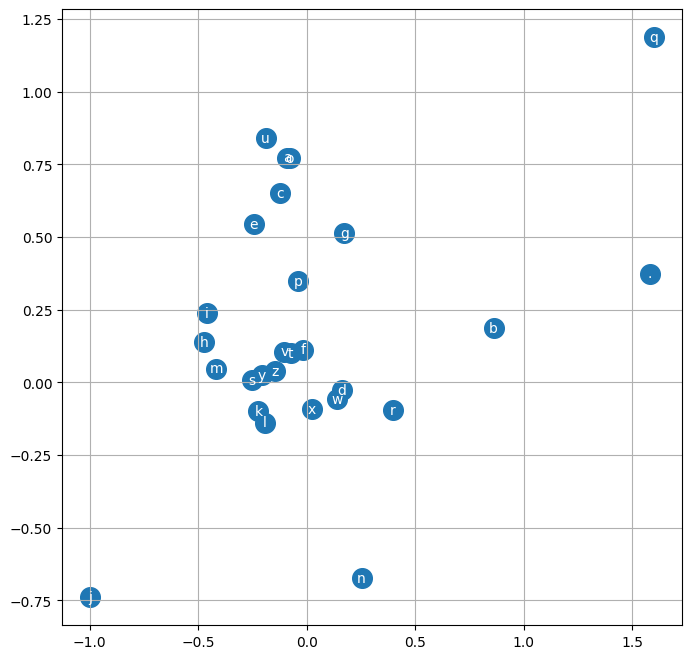

In [160]:
# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [ ]:
# training split, dev/validation split, test split
# 80%, 10%, 10%

In [161]:
context = [0] * block_size
C[torch.tensor([context])].shape

torch.Size([1, 3, 10])

In [163]:


# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

carmah.
amelle.
khi.
myli.
taty.
halayane.
rah.
braegerric.
kaeli.
nellara.
chaiif.
kaleigh.
ham.
joce.
quinn.
shon.
walianni.
wazelo.
dearynix.
kaekillsan.
